In [49]:
import numpy as np
import matplotlib.pyplot as plt

# Value Iteration算理論最優值

In [50]:
def value_iteration(P, R, discount_factor=0.9, theta=1e-8, max_iter=10000):
    n_states = len(P)
    n_actions = len(P[0])

    V = np.zeros(n_states)

    for i in range(max_iter):
        delta = 0

        V_old = V.copy()

        for s in range(n_states):
            q_values = []

            for a in range(n_actions):
                q_sa = 0

                for s_next in range(n_states):
                    prob = P[s][a][s_next]
                    reward = R[s][a][s_next]

                    q_sa += prob * (reward + discount_factor * V_old[s_next])

                q_values.append(q_sa)

            V[s] = max(q_values)

            delta = max(delta, abs(V[s] - V_old[s]))

        if delta < theta:
            break

    # 計算 Q*
    Q_star = np.zeros((n_states, n_actions))

    for s in range(n_states):
        for a in range(n_actions):
            for s_next in range(n_states):
                Q_star[s, a] += P[s][a][s_next] * (
                    R[s][a][s_next] + discount_factor * V[s_next]
                )

    optimal_policy = np.argmax(Q_star, axis=1)

    return V, Q_star, optimal_policy

In [51]:
def epsilon_greedy_value_iteration(P, R, epsilon=0.1, discount_factor=0.9, theta=1e-8, max_iter=10000):

    n_states = len(P)
    n_actions = len(P[0])

    V_bar = np.zeros(n_states)

    for i in range(max_iter):
        delta = 0
        V_bar_old = V_bar.copy()

        for s in range(n_states):
            q_values = np.zeros(n_actions)

            for a in range(n_actions):
                for s_next in range(n_states):
                    q_values[a] += P[s][a][s_next] * (
                        R[s][a][s_next] + discount_factor * V_bar_old[s_next]
                    )

            greedy_action = np.argmax(q_values)
            policy = np.ones(n_actions) * epsilon / n_actions
            policy[greedy_action] += 1 - epsilon

            V_bar[s] = np.sum(policy * q_values)

            delta = max(delta, abs(V_bar[s] - V_bar_old[s]))

        if delta < theta:
            break

    Q_bar = np.zeros((n_states, n_actions))

    for s in range(n_states):
        for a in range(n_actions):
            for s_next in range(n_states):
                Q_bar[s, a] += P[s][a][s_next] * (
                    R[s][a][s_next] + discount_factor * V_bar[s_next]
                )

    policy_matrix = np.zeros((n_states, n_actions))

    for s in range(n_states):
        greedy_action = np.argmax(Q_bar[s])
        policy_matrix[s] = epsilon / n_actions
        policy_matrix[s, greedy_action] += 1 - epsilon

    return V_bar, Q_bar, policy_matrix

# SARSA v.s Q-Learning

In [52]:
def epsilon_greedy(Q, state, epsilon):
    if np.random.rand() < epsilon:
        action = np.random.choice(len(Q[state]))
    else:
        candidate = np.flatnonzero(Q[state] == np.max(Q[state]))
        action = np.random.choice(candidate)
    return action

In [53]:
def sarsa_update(Q, S, A, R_next, S_next, A_next, discount_factor, learning_rate):
    Q[S][A] = Q[S][A] + learning_rate * (R_next + discount_factor * Q[S_next][A_next] - Q[S][A])
    return Q[S][A]

In [54]:
def q_update(Q, S, A, R_next, S_next, discount_factor, learning_rate):
    Q[S][A] = Q[S][A] + learning_rate * (R_next + discount_factor * np.max(Q[S_next]) - Q[S][A])
    return Q[S][A]

In [95]:
def run_simulate_environment_SARSA(P, R, policy, epsilon, steps, episodes, learning_rate, discount_factor, seed_num):
    #initialize environment seed
    np.random.seed(seed_num)
    #initialize Q-table
    Q = np.zeros((len(P),len(P[0])), dtype = float)
    visit_count = np.zeros((len(P), len(P[0])))
    #Store episode history
    total_return_list = []
    Q_table_history = []

    # Main Episodes loop
    for _ in range(episodes):
        total_return = 0
        #initialize state, action
        current_state = 0 # 每回合的初始狀態都是0
        current_action = policy(Q, current_state, epsilon)

        #Main steps loop per episode (Interact with Environment)
        for t in range(steps):
            visit_count[current_state][current_action] += 1
            learning_rate = 1 / np.sqrt(visit_count[current_state, current_action])
            #interact with env
            next_state = np.random.choice(len(P), p = P[current_state][current_action])
            #reward = R[current_state][current_action][next_state] + np.random.normal(0,1)
            reward = R[current_state][current_action][next_state] 
            next_action = policy(Q, next_state, epsilon)
            #---------------------------------------------------------------------------------
            #total_return += (discount_factor**t) * reward #1
            total_return += reward 
            #---------------------------------------------------------------------------------
            # Main update algorithm
            sarsa_update(Q, current_state, current_action, reward, next_state, next_action, discount_factor, learning_rate)
            # update state,action
            current_state = next_state
            current_action = next_action
        #1
        total_return_list.append(total_return)
        #2
        Q_table_history.append(Q.copy())

    return Q, total_return_list, Q_table_history

In [105]:
def run_simulate_environment_SARSA_decaying(P, R, policy, epsilon, steps, episodes, learning_rate, discount_factor, seed_num):
    #initialize environment seed
    np.random.seed(seed_num)
    #initialize Q-table
    Q = np.zeros((len(P),len(P[0])), dtype = float)
    visit_count = np.zeros((len(P), len(P[0])))
    state_visit_count = np.zeros(len(P))
    #Store episode history
    total_return_list = []
    Q_table_history = []

    # Main Episodes loop
    for i in range(episodes):
        total_return = 0

        #initialize state, action
        current_state = 0 # 每回合的初始狀態都是0
        state_visit_count[current_state] += 1
        current_action = policy(Q, current_state, np.sqrt(epsilon/state_visit_count[current_state]))

        #Main steps loop per episode (Interact with Environment)
        for t in range(steps):
            visit_count[current_state, current_action] += 1
            learning_rate = 1 / np.sqrt(visit_count[current_state, current_action])
            #interact with env
            next_state = np.random.choice(len(P), p = P[current_state][current_action])
            #reward = R[current_state][current_action][next_state] + np.random.normal(0,1)
            reward = R[current_state][current_action][next_state] 
            #state visit
            #state_visit_count[next_state] += 1
            eps_next_s = np.sqrt(epsilon/visit_count[current_state, current_action])
            next_action = policy(Q, next_state, eps_next_s)
            #---------------------------------------------------------------------------------
            #total_return += (discount_factor**t) * reward #1
            total_return += reward 
            #---------------------------------------------------------------------------------
            # Main update algorithm
            sarsa_update(Q, current_state, current_action, reward, next_state, next_action, discount_factor, learning_rate)
            # update state,action
            current_state = next_state
            current_action = next_action
        #1
        total_return_list.append(total_return)
        #2
        Q_table_history.append(Q.copy())

    return Q, total_return_list, Q_table_history

In [96]:
def run_simulate_environment_QL(P, R, policy, epsilon, steps, episodes, learning_rate, discount_factor, seed_num):
    #initialize environment seed
    np.random.seed(seed_num)
    #initialize Q-table
    Q = np.zeros((len(P),len(P[0])), dtype = float)
    visit_count = np.zeros((len(P), len(P[0])))
    #Store episode history
    total_return_list = []
    Q_table_history = []

    # Main Episodes loop
    for _ in range(episodes):
        total_return = 0
        #initialize state, action
        current_state = 0 # 每回合的初始狀態都是0
        current_action = policy(Q, current_state, epsilon)

        #Main steps loop per episode (Interact with Environment)
        for t in range(steps):
            visit_count[current_state, current_action] += 1
            learning_rate = 1/ np.sqrt(visit_count[current_state, current_action])
            #interact with env
            next_state = np.random.choice(len(P), p = P[current_state][current_action])
            #reward = R[current_state][current_action][next_state] + np.random.normal(0,1)
            reward = R[current_state][current_action][next_state] 
            next_action = policy(Q, next_state, epsilon)
            #---------------------------------------------------------------------------------
            #total_return += (discount_factor**t) * reward
            total_return += reward 
            #---------------------------------------------------------------------------------
            # Main update algorithm
            q_update(Q, current_state, current_action, reward, next_state, discount_factor, learning_rate)
            # update state,action
            current_state = next_state
            current_action = next_action
        #1
        total_return_list.append(total_return)
        #2
        Q_table_history.append(Q.copy())


    return Q, total_return_list, Q_table_history

In [98]:
# 實驗設定
P = {
    0: {  # 目前狀態：差
        0: [0.6, 0.35, 0.05],  # 保守
        1: [0.7, 0.25, 0.05],  # 維持
        2: [0.5, 0.35, 0.15],  # 大膽
    },
    1: {  # 目前狀態：中等
        0: [0.2, 0.65, 0.15],  # 保守
        1: [0.25, 0.55, 0.20], # 維持
        2: [0.35, 0.30, 0.35], # 大膽
    },
    2: {  # 目前狀態：良好
        0: [0.05, 0.35, 0.60], # 保守
        1: [0.10, 0.30, 0.60], # 維持
        2: [0.25, 0.25, 0.50], # 大膽
    }}

R = {
    0: {  # 目前狀態：差
        0: [-1, 0, 1],         # 保守
        1: [-2, 0, 2],         # 維持
        2: [-4, 1, 4],         # 大膽
    },
    1: {  # 目前狀態：中等
        0: [-2, 1, 2],         # 保守
        1: [-3, 2, 4],         # 維持
        2: [-5, 1, 6],         # 大膽
    },
    2: {  # 目前狀態：良好
        0: [-1, 2, 3],         # 保守 
        1: [-2, 3, 5],         # 維持
        2: [-6, 1, 8],         # 大膽 
    }
}
# P = {
#     0: {  # 差
#         0: [0.85, 0.14, 0.01],  # 保守：非常穩，但幾乎不會變好
#         1: [0.65, 0.30, 0.05],  # 維持：中等
#         2: [0.90, 0.05, 0.05],  # 大膽：高機率失敗，小機率大成功
#     },
#     1: {  # 中等
#         0: [0.20, 0.75, 0.05],
#         1: [0.25, 0.60, 0.15],
#         2: [0.80, 0.10, 0.10],
#     },
#     2: {  # 良好
#         0: [0.02, 0.18, 0.80],
#         1: [0.10, 0.35, 0.55],
#         2: [0.70, 0.10, 0.20],
#     }
# }

# R = {
#     0: {  # 差
#         0: [-1, 1, 3],
#         1: [-5, 3, 10],
#         2: [-80, -30, 300],
#     },
#     1: {  # 中等
#         0: [-2, 2, 5],
#         1: [-8, 5, 15],
#         2: [-120, -40, 500],
#     },
#     2: {  # 良好
#         0: [0, 5, 10],
#         1: [-10, 10, 30],
#         2: [-200, -60, 1000],
#     }
# }

episodes = 1000
steps = 1000
learning_rate = 1
discount_factor = 0.95
epsilon = 1
policy = epsilon_greedy

In [77]:
# store all seed Q-table 
all_seed_Q_table_SARSA = []
all_seed_Q_table_rSARSA = []
all_seed_Q_table_QL = []
all_returns_SARSA = []
all_returns_rSARSA = []
all_returns_QL = []

for seed_num in range(1,11):
    Q_SARSA, total_return_list_SARSA, Q_table_history_SARSA = run_simulate_environment_SARSA(P, R, policy, epsilon, steps, episodes, learning_rate, discount_factor, seed_num)
    Q_rSARSA, total_return_list_rSARSA, Q_table_history_rSARSA = run_simulate_environment_SARSA_decaying(P, R, policy, epsilon, steps, episodes, learning_rate, discount_factor, seed_num)
    Q_QL, total_return_list_QL, Q_table_history_QL = run_simulate_environment_QL(P, R, policy, epsilon, steps, episodes, learning_rate, discount_factor, seed_num)

    all_seed_Q_table_SARSA.append(Q_table_history_SARSA)
    all_seed_Q_table_rSARSA.append(Q_table_history_rSARSA)
    all_seed_Q_table_QL.append(Q_table_history_QL)
    all_returns_SARSA.append(total_return_list_SARSA)
    all_returns_rSARSA.append(total_return_list_rSARSA)
    all_returns_QL.append(total_return_list_QL)


KeyboardInterrupt: 

In [107]:
# store all seed Q-table 
all_seed_Q_table_SARSA = []
all_seed_Q_table_rSARSA = []
all_seed_Q_table_QL = []
all_returns_SARSA = []
all_returns_rSARSA = []
all_returns_QL = []

seed_num = 42
Q_SARSA, total_return_list_SARSA, Q_table_history_SARSA = run_simulate_environment_SARSA(P, R, policy, epsilon, steps, episodes, learning_rate, discount_factor, seed_num)
Q_rSARSA, total_return_list_rSARSA, Q_table_history_rSARSA= run_simulate_environment_SARSA_decaying(P, R, policy, epsilon, steps, episodes, learning_rate, discount_factor, seed_num)
Q_QL, total_return_list_QL, Q_table_history_QL= run_simulate_environment_QL(P, R, policy, epsilon, steps, episodes, learning_rate, discount_factor, seed_num)

all_seed_Q_table_SARSA.append(Q_table_history_SARSA)
all_seed_Q_table_rSARSA.append(Q_table_history_rSARSA)
all_seed_Q_table_QL.append(Q_table_history_QL)
all_returns_SARSA.append(total_return_list_SARSA)
all_returns_rSARSA.append(total_return_list_rSARSA)
all_returns_QL.append(total_return_list_QL)

In [108]:
# 算理論最優值
V_star, Q_star, optimal_policy = value_iteration(P, R, discount_factor)

print(f"V*:\n{V_star}")

print(f"Q*:\n{Q_star}")

print(f"Optimal policy:\n{optimal_policy}")

V*:
[23.08681929 26.27391105 31.11933133]
Q*:
[[22.82373066 21.77095694 23.0868193 ]
 [25.59514045 26.27391106 26.16160973]
 [30.0207182  31.11933134 29.25485584]]
Optimal policy:
[2 1 1]


In [109]:
# 算epsilon-greedy理論最優值
V_bar, Q_bar, stationary_policy = epsilon_greedy_value_iteration(P, R, epsilon, discount_factor)

print(f"V_bar:\n{V_bar}")

print(f"Q_bar:\n{Q_bar}")

print(f"stationary policy:\n{stationary_policy}")

V_bar:
[12.22442155 15.58146539 19.39886864]
Q_bar:
[[12.52020379 11.45128462 12.70177626]
 [15.25853376 15.88040083 15.60546163]
 [19.26885239 20.35939281 18.56836075]]
stationary policy:
[[0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.33333333]]


In [110]:
all_seed_Q_table_SARSA = np.array(all_seed_Q_table_SARSA)
all_seed_Q_table_rSARSA = np.array(all_seed_Q_table_rSARSA)
all_seed_Q_table_QL = np.array(all_seed_Q_table_QL)
all_returns_SARSA = np.array(all_returns_SARSA)
all_returns_rSARSA = np.array(all_returns_rSARSA)
all_returns_QL = np.array(all_returns_QL)


print(np.shape(all_seed_Q_table_SARSA)) # (seeds, episodes, state, action)
print(np.shape(all_seed_Q_table_rSARSA))
print(np.shape(all_seed_Q_table_QL))
print(np.shape(all_returns_SARSA))
print(np.shape(all_returns_rSARSA))
print(np.shape(all_returns_QL))


(1, 1000, 3, 3)
(1, 1000, 3, 3)
(1, 1000, 3, 3)
(1, 1000)
(1, 1000)
(1, 1000)


In [111]:
def ci95(data):
    mean = data.mean(axis=0)
    std = data.std(axis=0, ddof=1)
    se = std/np.sqrt(data.shape[0])
    ci = 1.96*se
    return mean, ci

/home/larry/my_rl_project/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/larry/my_rl_project/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:208: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


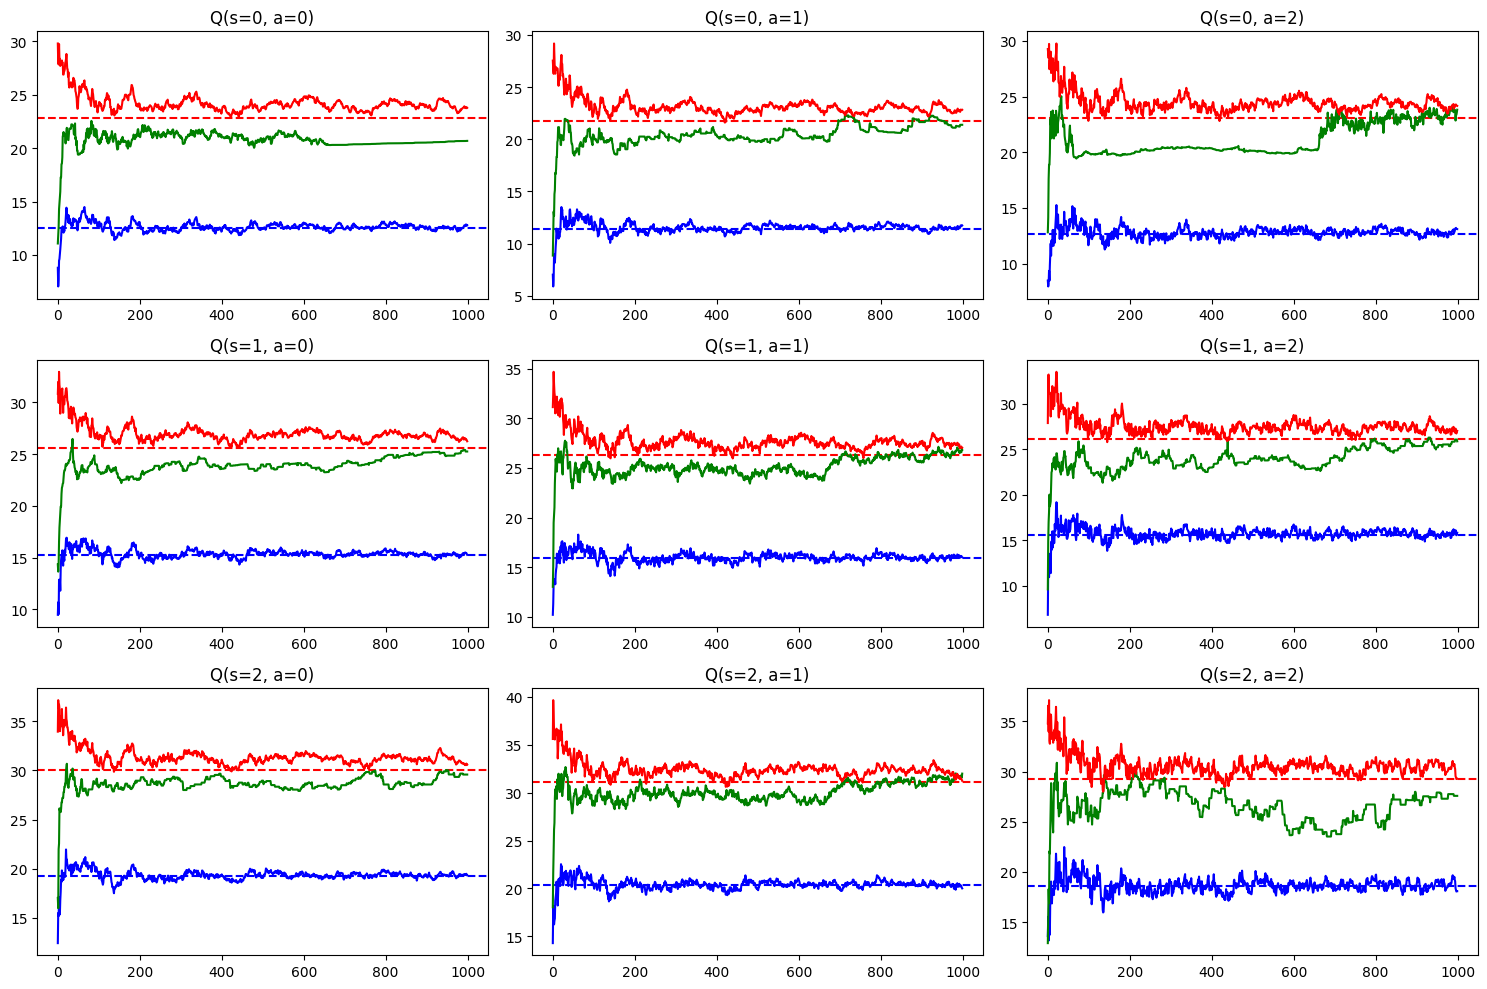

In [112]:
fig, axes = plt.subplots(3, 3, figsize=(15,10))

for s in range(3):
    for a in range(3):
        ax = axes[s, a]

        q_sarsa = all_seed_Q_table_SARSA[:, :, s, a]
        q_rsarsa = all_seed_Q_table_rSARSA[:, :, s, a]
        q_ql    = all_seed_Q_table_QL[:, :, s, a]

        mean_sarsa, ci_sarsa = ci95(q_sarsa)
        mean_rsarsa, ci_rsarsa = ci95(q_rsarsa)
        mean_ql, ci_ql       = ci95(q_ql)

        x = np.arange(len(mean_sarsa))

        ax.axhline(Q_star[s, a], linestyle="--", label="Q*", color= "red")
        ax.axhline(Q_bar[s, a], linestyle="--", label="Q-bar", color= "blue")
        
        ax.plot(x, mean_sarsa, color="blue")
        ax.fill_between(x, mean_sarsa-ci_sarsa, mean_sarsa+ci_sarsa, alpha=0.2)

        ax.plot(x, mean_rsarsa, color="green")
        ax.fill_between(x, mean_rsarsa-ci_rsarsa, mean_rsarsa+ci_rsarsa, alpha=0.2)

        ax.plot(x, mean_ql, color="red")
        ax.fill_between(x, mean_ql-ci_ql, mean_ql+ci_ql, alpha=0.2)

        ax.set_title(f"Q(s={s}, a={a})")

plt.tight_layout()
plt.show()

In [115]:
all_seed_Q_table_SARSA

array([[[[ 8.79279202,  7.02363423,  8.47808416],
         [ 9.4798714 , 10.20371462,  6.79356756],
         [12.44257587, 14.29201449, 13.60974653]],

        [[ 7.04440257,  5.9013085 ,  7.95302886],
         [10.69078339, 11.30558145, 12.10996146],
         [15.50597063, 18.1889729 , 15.5347011 ]],

        [[ 7.7432939 ,  6.52719174,  8.21263592],
         [ 9.53252085, 13.40200604, 12.07365847],
         [15.1877926 , 17.16602052, 13.15682503]],

        ...,

        [[12.77317651, 11.73208816, 13.12956129],
         [15.44251552, 16.13428413, 15.53958882],
         [19.48797918, 20.19660827, 18.04902667]],

        [[12.72840996, 11.69821917, 13.10275219],
         [15.34778342, 16.04191576, 15.68511823],
         [19.33500097, 20.08251211, 18.08004348]],

        [[12.77865042, 11.73863501, 13.09960197],
         [15.27323643, 16.0056237 , 15.82332507],
         [19.34204909, 20.00587783, 18.08115891]]]], shape=(1, 1000, 3, 3))

In [116]:
all_seed_Q_table_rSARSA 

array([[[[11.0684098 ,  8.85992239, 12.81277465],
         [14.34735965, 13.02419514,  9.59247951],
         [17.03594072, 18.04001131, 12.90523213]],

        [[11.94652942, 10.76817298, 14.13512907],
         [13.65134529, 15.04824844, 14.96384818],
         [15.99546149, 21.62701466, 15.53371653]],

        [[12.59113966, 13.06846338, 17.61012582],
         [14.33781622, 19.49446029, 17.03019897],
         [22.00057395, 23.6671914 , 18.29305994]],

        ...,

        [[20.67787096, 21.38169882, 23.34914386],
         [25.25796952, 26.58859075, 26.06170644],
         [29.57821313, 31.740198  , 27.5802206 ]],

        [[20.67787096, 21.38169882, 23.54547603],
         [25.25796952, 26.92584262, 26.06170644],
         [29.57821313, 31.5712726 , 27.5802206 ]],

        [[20.67787096, 21.38169882, 23.81489838],
         [25.25796952, 26.83262673, 25.86890303],
         [29.57821313, 31.98545059, 27.5802206 ]]]], shape=(1, 1000, 3, 3))

In [117]:
all_seed_Q_table_QL 

array([[[[29.79699612, 27.5232482 , 29.25681126],
         [30.8332006 , 31.13505433, 27.87944691],
         [33.93858839, 35.60172747, 34.79495136]],

        [[28.01632082, 26.74440356, 28.86553413],
         [31.98305707, 32.4357474 , 33.12237247],
         [37.141228  , 39.65524441, 36.5618728 ]],

        [[27.83173082, 26.26527645, 28.44720852],
         [29.94829871, 34.69318921, 33.21510964],
         [36.37138248, 37.85389989, 33.97993015]],

        ...,

        [[23.76879581, 22.81598154, 24.18903534],
         [26.42110262, 27.16447401, 26.72627469],
         [30.69389488, 31.43237399, 29.25760587]],

        [[23.73751377, 22.77835774, 24.17777227],
         [26.32005031, 27.05854582, 26.87734191],
         [30.53592261, 31.33093766, 29.26395835]],

        [[23.77127938, 22.81680752, 24.15738714],
         [26.24560959, 27.03247094, 27.02207881],
         [30.57678729, 31.23978198, 29.28471742]]]], shape=(1, 1000, 3, 3))